In [38]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [39]:
data = pd.read_csv('reddit_dead_internet_analysis_2026.csv')
print(data.columns)
columns_to_drop = ['subreddit', 'comment_id', 'bot_type_label', 'bot_probability', 'contains_links', 'avg_word_length']
data2 = data.copy()
del data2['comment_id']
del data2['bot_probability']
del data2['bot_type_label']
data = data.drop(columns=columns_to_drop)
data['hum_val'] = (data['account_age_days'] + data['user_karma']) * data['reply_delay_seconds']
columns_to_drop = ['account_age_days', 'user_karma', 'reply_delay_seconds']
data = data.drop(columns=columns_to_drop)
print(data.columns)
print(data)
print(data.columns.tolist())



Index(['comment_id', 'subreddit', 'account_age_days', 'user_karma',
       'reply_delay_seconds', 'sentiment_score', 'avg_word_length',
       'contains_links', 'is_bot_flag', 'bot_type_label', 'bot_probability'],
      dtype='str')
Index(['sentiment_score', 'is_bot_flag', 'hum_val'], dtype='str')
     sentiment_score  is_bot_flag    hum_val
0              -0.60        False   67589424
1               0.15        False    4613378
2               0.35        False  106906353
3              -0.74        False   93226815
4              -0.96        False   44554969
..               ...          ...        ...
495            -0.21         True      21295
496             0.71         True     226340
497             0.21        False   35695025
498            -0.38        False   12233532
499            -0.32        False   19997235

[500 rows x 3 columns]
['sentiment_score', 'is_bot_flag', 'hum_val']


In [40]:
y = data['is_bot_flag']
X = data.drop(columns=['is_bot_flag'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

       False       1.00      1.00      1.00        52
        True       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[52  0]
 [ 0 48]]


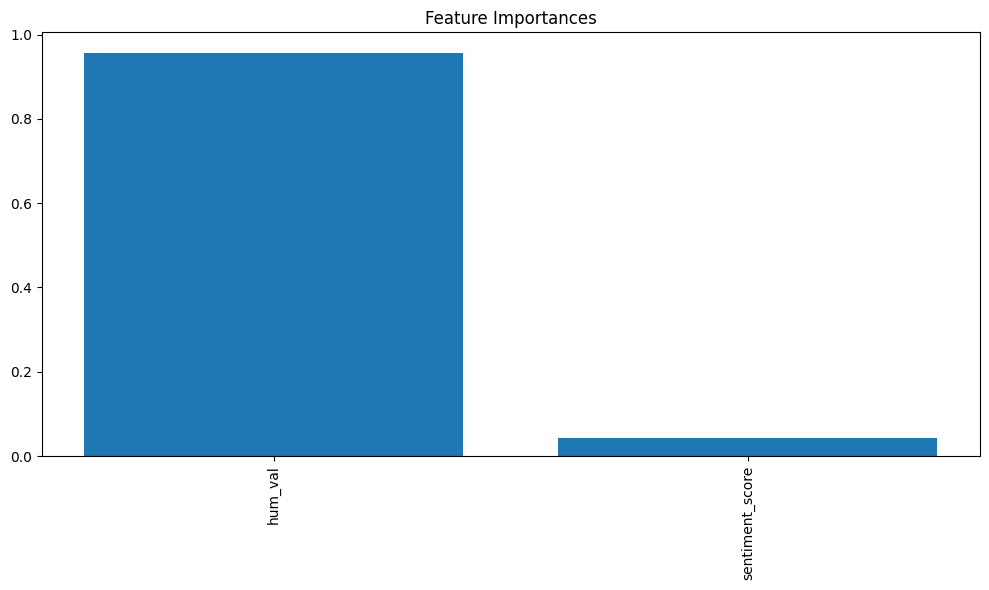

In [41]:
feature_importances = model.feature_importances_ 
features = X.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

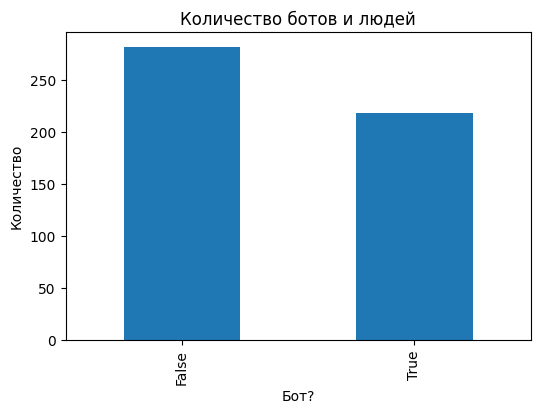

In [42]:
plt.figure(figsize=(6,4))
data2["is_bot_flag"].value_counts().plot(kind="bar")
plt.title("Количество ботов и людей")
plt.xlabel("Бот?")
plt.ylabel("Количество")
plt.show()

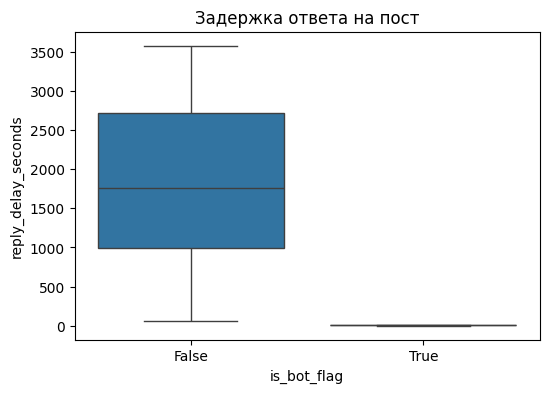

In [43]:
plt.figure(figsize=(6,4))
sns.boxplot(x="is_bot_flag", y="reply_delay_seconds", data=data2)
plt.title("Задержка ответа на пост")
plt.show()

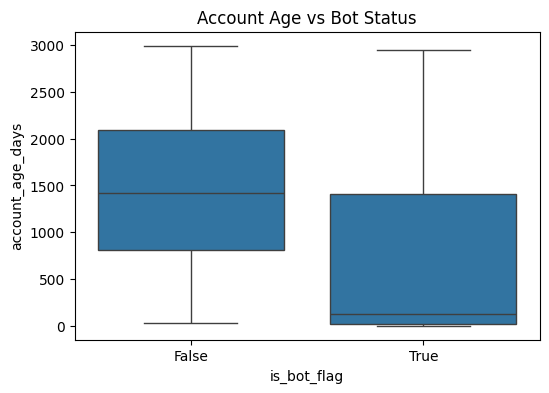

In [44]:
plt.figure(figsize=(6,4))
sns.boxplot(x="is_bot_flag", y="account_age_days", data=data2)
plt.title("Account Age vs Bot Status")
plt.show()

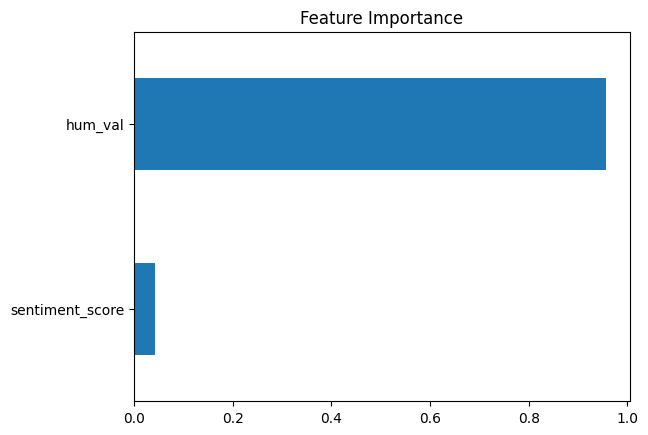

In [45]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

In [48]:
account_age_days = int(input("Enter account age in days: "))
user_karma = int(input("Enter user karma: "))
reply_delay_seconds = int(input("Enter reply delay in seconds: "))
sentiment_score = float(input("Enter sentiment score: "))
hum_val = (account_age_days + user_karma) * reply_delay_seconds

# Создаём DataFrame с теми же столбцами в том же порядке, как при обучении
input_data = pd.DataFrame({
    'sentiment_score': [sentiment_score],
    'hum_val': [hum_val]
})

prediction = model.predict(input_data)
print(f"Prediction: {prediction} ")

Prediction: [False] 
